In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/cleaned/billings_cleaned.csv', low_memory=False)

# Parse date columns
for col in ['prospect_renewal_date', 'registration_date', 'closed_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape: (113766, 35)
Columns: ['co_ref', 'renewal_month', 'sustainability_score', 'total_renewal_score_new', 'auto_renewal_score', 'status_scores', 'anchoring_score', 'tenure_scores', 'current_anchorings', 'payment_timeframe', 'registration_date', 'proforma_account_stage', 'proforma_audit_status', 'current_auto_renewal_flag', 'current_world_pay_token', 'renewal_score_at_release', 'proforma_membership_status', 'proforma_approved_lists', 'tenure_years', 'band', 'prospect_renewal_date', 'closed_date', 'prospect_status', 'total_net_paid', 'prospect_outcome', 'payment_method', 'amount', 'connection_group', 'tenure_group', '#_of_connection', 'last_band', 'last_connections', 'renewal_year', 'last_years_price', 'price_change']


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113766 entries, 0 to 113765
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   co_ref                      113766 non-null  object        
 1   renewal_month               113766 non-null  object        
 2   sustainability_score        113766 non-null  float64       
 3   total_renewal_score_new     113766 non-null  float64       
 4   auto_renewal_score          113766 non-null  int64         
 5   status_scores               113766 non-null  int64         
 6   anchoring_score             113766 non-null  float64       
 7   tenure_scores               113766 non-null  float64       
 8   current_anchorings          113766 non-null  int64         
 9   payment_timeframe           113766 non-null  float64       
 10  registration_date           112794 non-null  datetime64[ns]
 11  proforma_account_stage      113766 non-

In [3]:
df.describe()

,sustainability_score,total_renewal_score_new,auto_renewal_score,status_scores,anchoring_score,tenure_scores,current_anchorings,payment_timeframe,registration_date,renewal_score_at_release,...,tenure_years,prospect_renewal_date,closed_date,total_net_paid,amount,#_of_connection,last_connections,renewal_year,last_years_price,price_change
count,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,112794,113766.000000,...,113766.000000,113766,113766,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000
mean,8.613320,41.904862,8.471960,7.097217,8.704182,9.018182,3.102324,-6.547316,2017-10-14 14:14:16.768976896,25.774960,...,6.842897,2024-08-19 02:27:18.521175040,2024-08-16 00:36:21.150782976,1058.690133,1087.292319,3.222228,2.090853,2024.179113,582.684886,476.005247
min,8.000000,30.500000,8.000000,0.000000,7.500000,7.000000,0.000000,-1081.000000,2000-01-01 00:00:00,15.500000,...,0.000000,2023-01-01 00:00:00,2021-09-15 00:00:00,0.000000,0.000000,0.000000,0.000000,2023.000000,0.000000,-3238.000000
25%,8.000000,41.000000,8.000000,7.000000,8.500000,8.500000,1.000000,-13.000000,2014-05-02 00:00:00,24.500000,...,2.000000,2023-10-28 00:00:00,2023-10-27 00:00:00,684.000000,699.000000,1.000000,0.000000,2023.000000,0.000000,65.000000
50%,8.000000,43.500000,8.000000,9.000000,8.500000,9.500000,1.000000,0.000000,2019-02-12 00:00:00,26.000000,...,5.000000,2024-08-24 00:00:00,2024-08-20 00:00:00,919.000000,924.000000,1.000000,0.000000,2024.000000,579.000000,308.400000
75%,9.500000,45.000000,9.000000,9.000000,9.500000,9.500000,3.000000,0.000000,2022-03-23 00:00:00,27.500000,...,10.000000,2025-06-10 00:00:00,2025-06-09 00:00:00,1214.000000,1244.000000,3.000000,2.000000,2025.000000,934.000000,749.000000
max,9.500000,46.500000,9.000000,9.000000,9.500000,9.500000,209.000000,482.000000,2026-03-24 00:00:00,28.200000,...,26.000000,2026-05-31 00:00:00,2026-03-16 00:00:00,18326.000000,17877.000000,197.000000,197.000000,2026.000000,12616.000000,9346.000000
std,0.692147,4.395806,0.499215,3.347584,0.735701,0.610783,6.485866,25.960106,NaN,1.886469,...,5.370246,NaN,NaN,636.291668,651.869848,6.551785,5.584893,0.948112,620.701351,519.723789


## 2. Missing Values Analysis

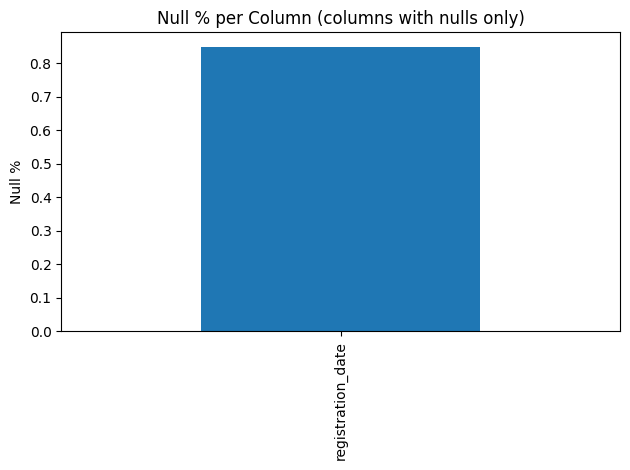


Missing values summary:
registration_date    0.85
dtype: float64


In [4]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

cols_with_nulls = null_pct[null_pct > 0]
if len(cols_with_nulls) > 0:
    cols_with_nulls.plot(kind='bar')
    plt.title('Null % per Column (columns with nulls only)')
    plt.ylabel('Null %')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values!')

print('\nMissing values summary:')
print(cols_with_nulls)

## 3. Target Variable Analysis (Prospect_Outcome / Churn)

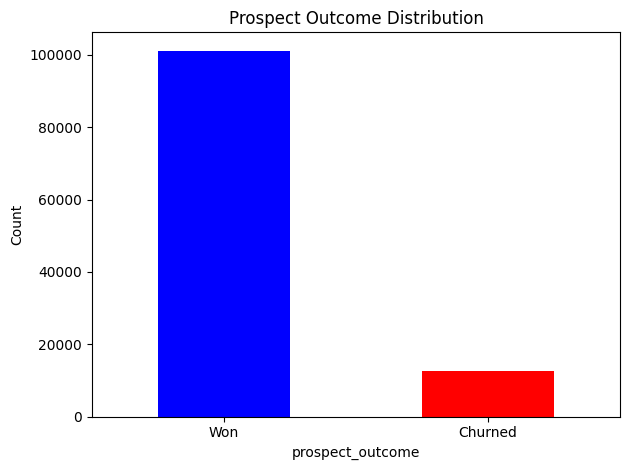

In [5]:
# Create binary churn label
df['is_churned'] = (df['prospect_outcome'] == 'Churned').astype(int)

outcome_counts = df['prospect_outcome'].value_counts()
outcome_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Prospect Outcome Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/billings_target_distribution.png')
plt.show()

In [6]:
outcome_pct = df['prospect_outcome'].value_counts(normalize=True) * 100
print(f'Churn Rate: {outcome_pct.get("Churned", 0):.1f}%')
print(f'Win Rate: {outcome_pct.get("Won", 0):.1f}%')

Churn Rate: 11.1%
Win Rate: 88.9%


## 4. Numerical Features Distribution

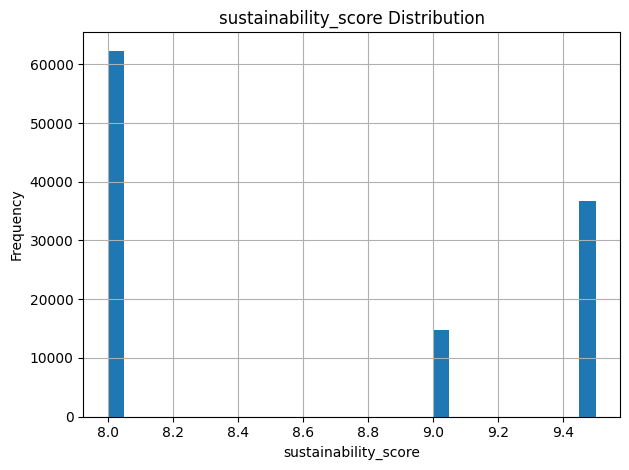

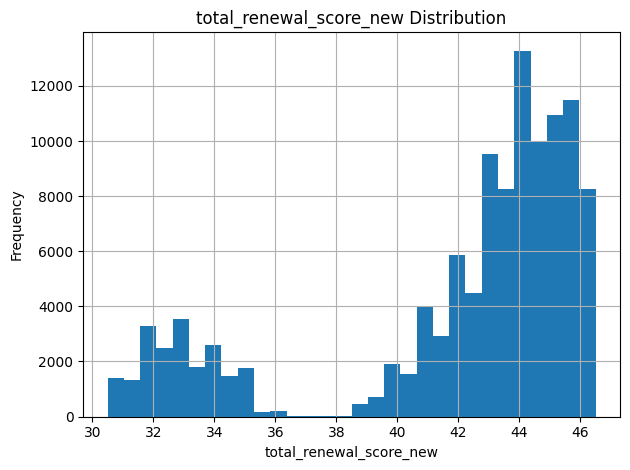

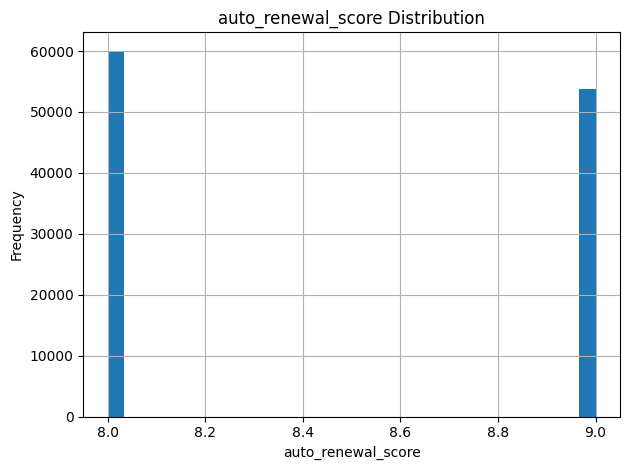

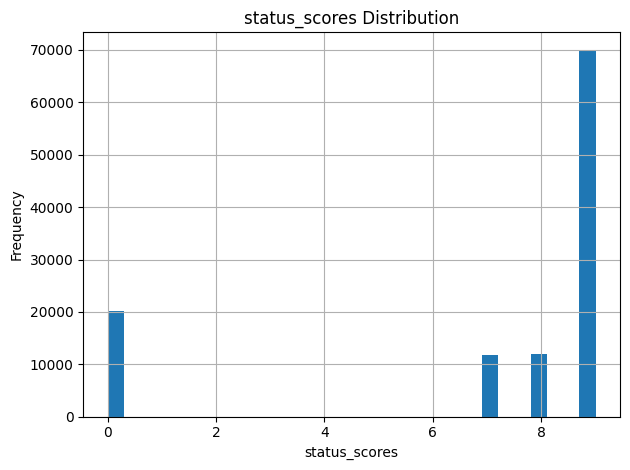

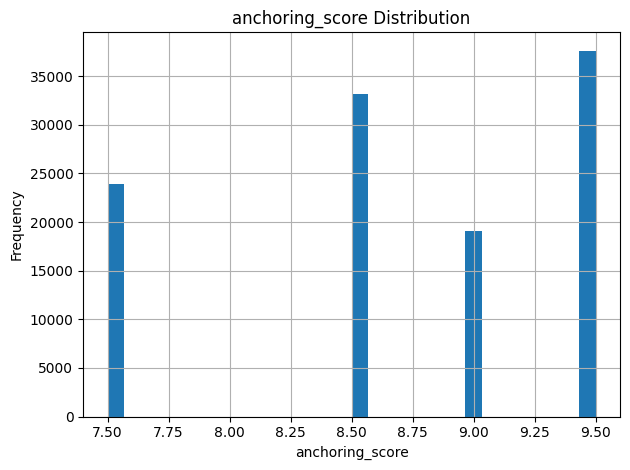

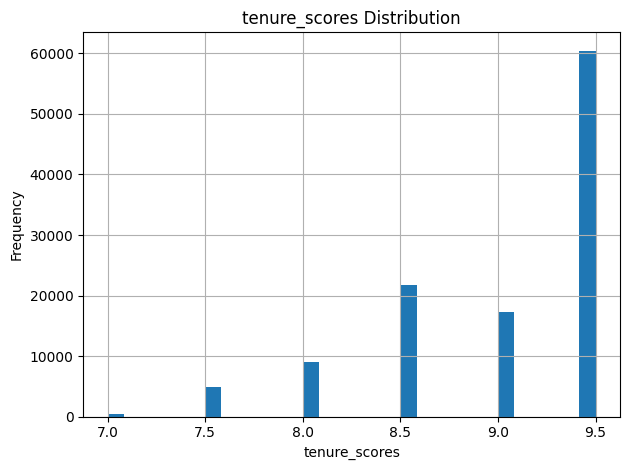

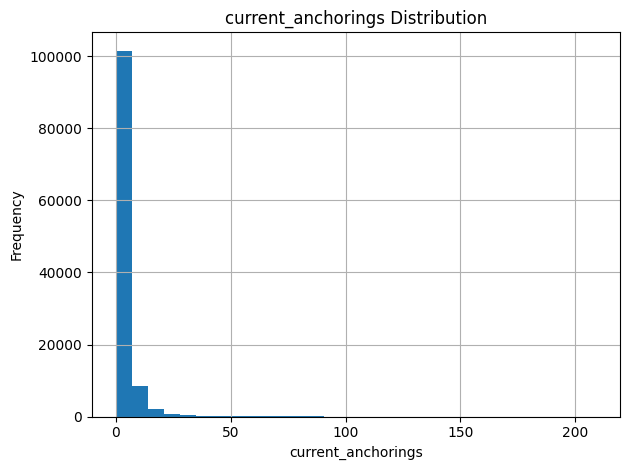

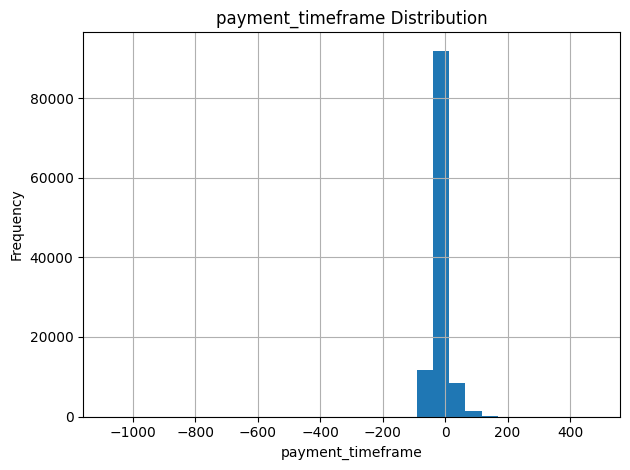

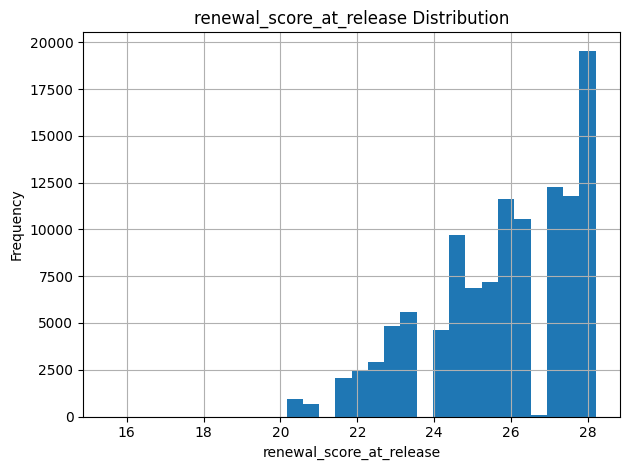

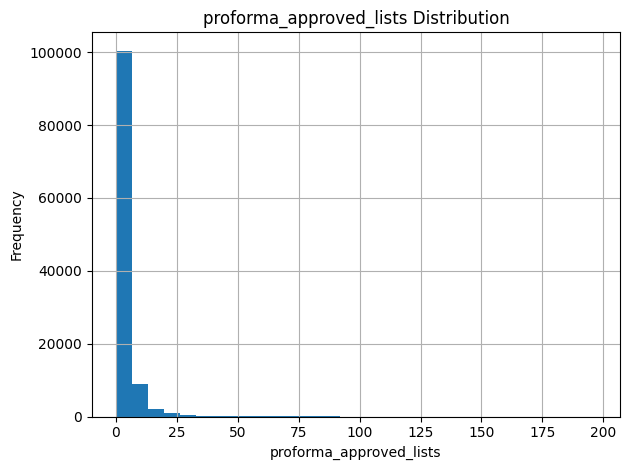

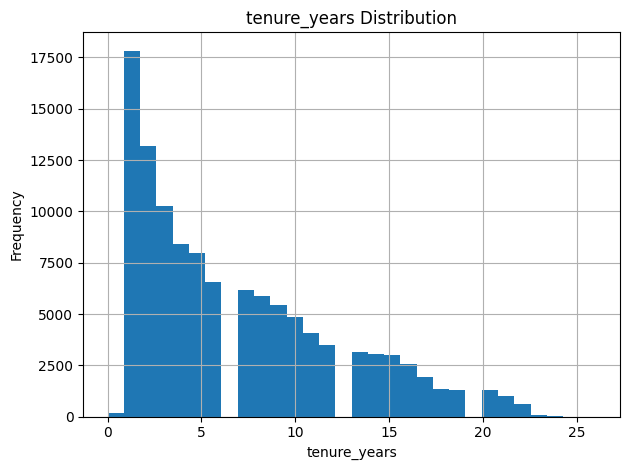

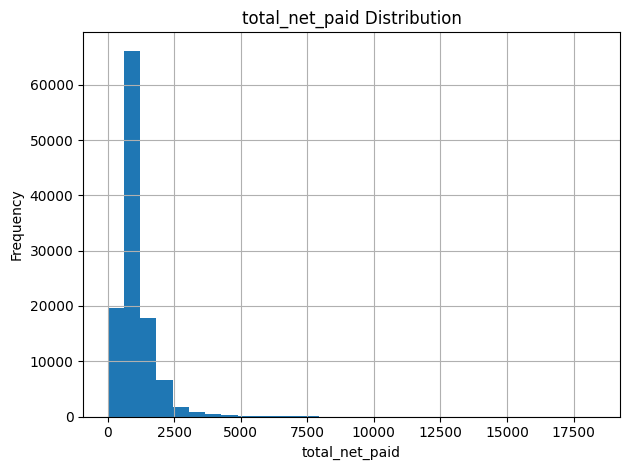

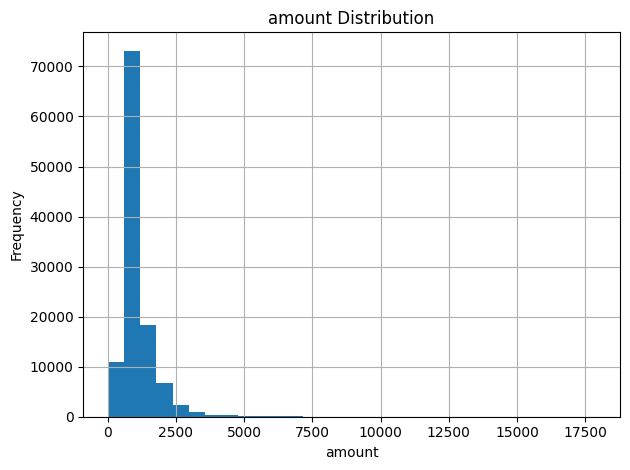

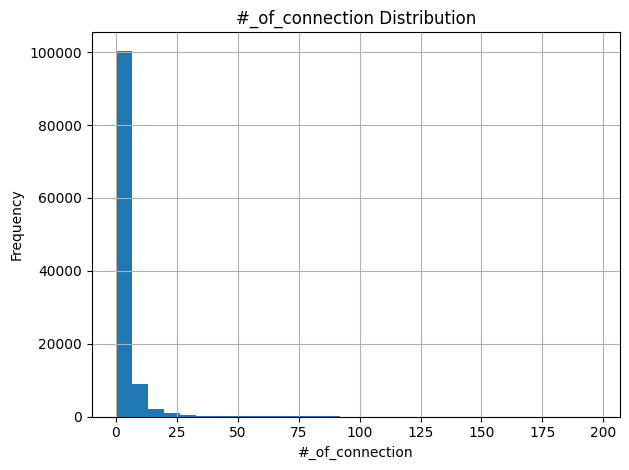

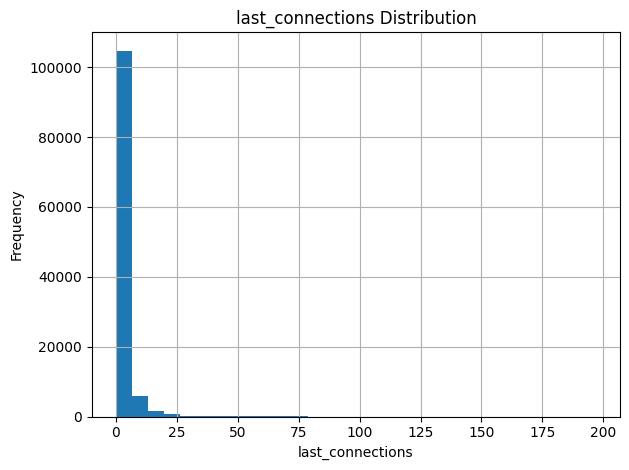

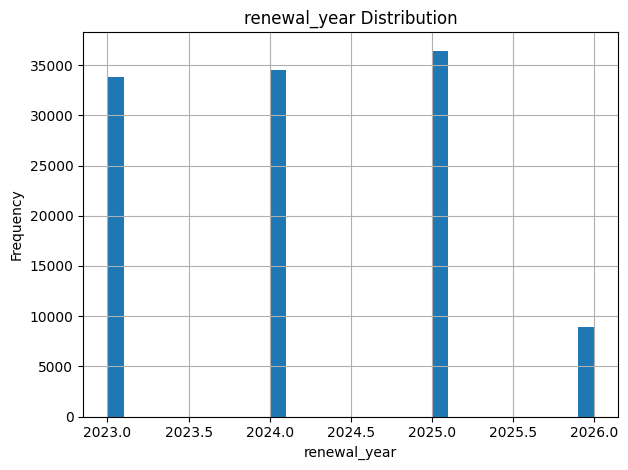

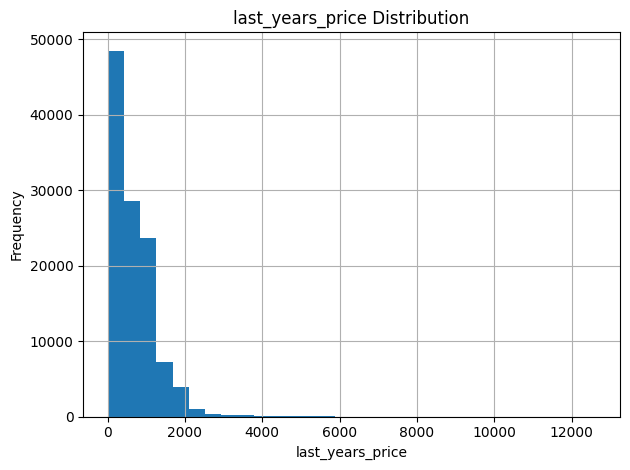

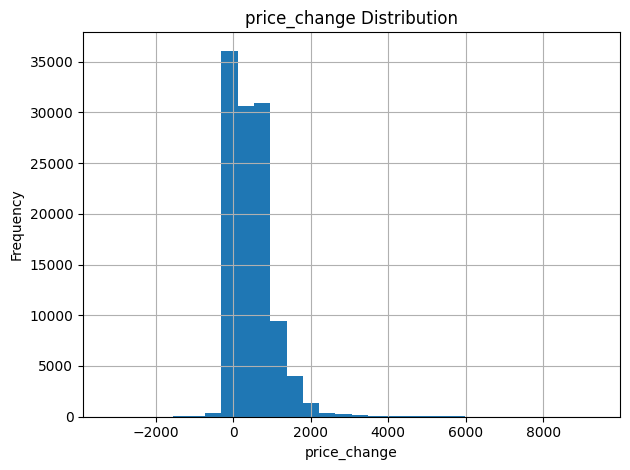

In [7]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['is_churned']]

for col in numeric_cols:
    df[col].dropna().hist(bins=30)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## 6. Categorical Features Analysis

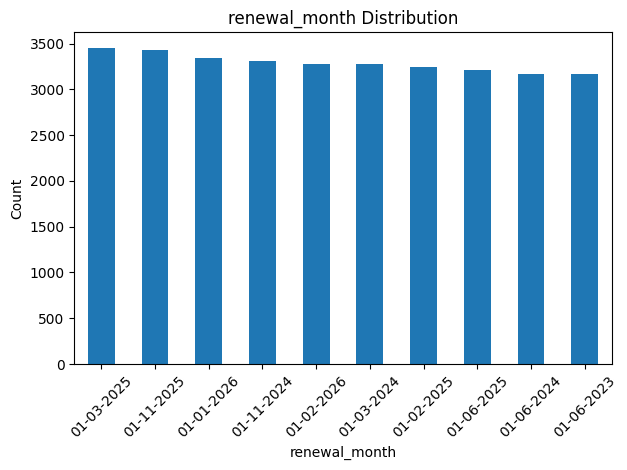

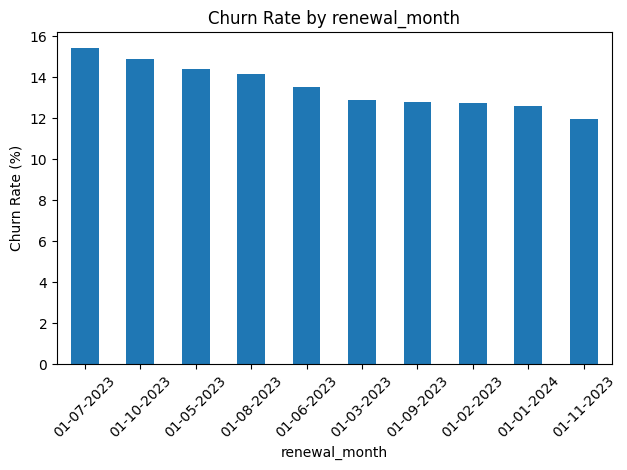

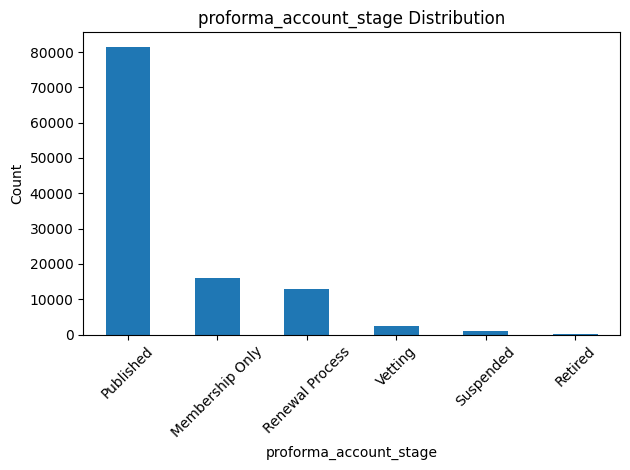

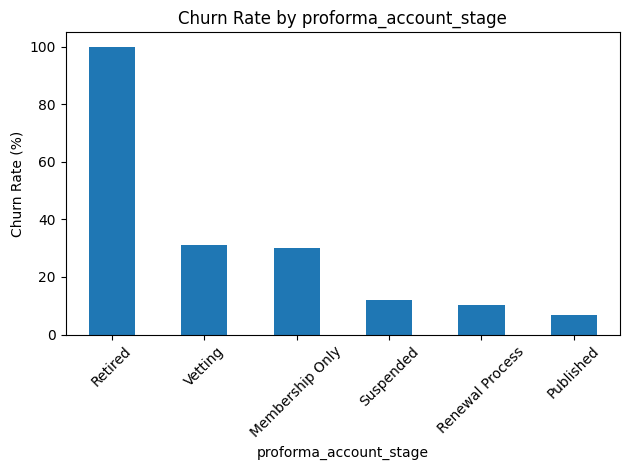

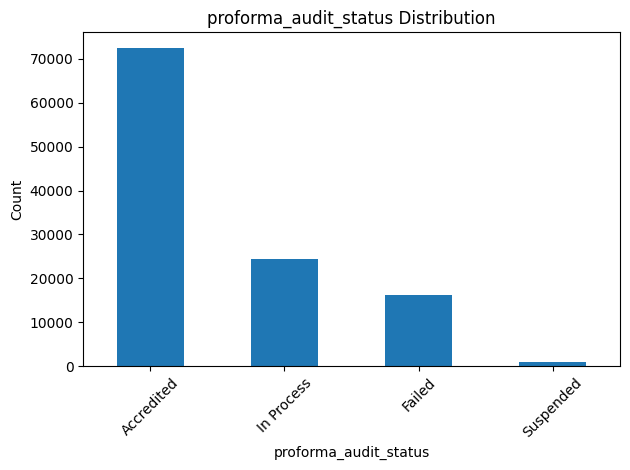

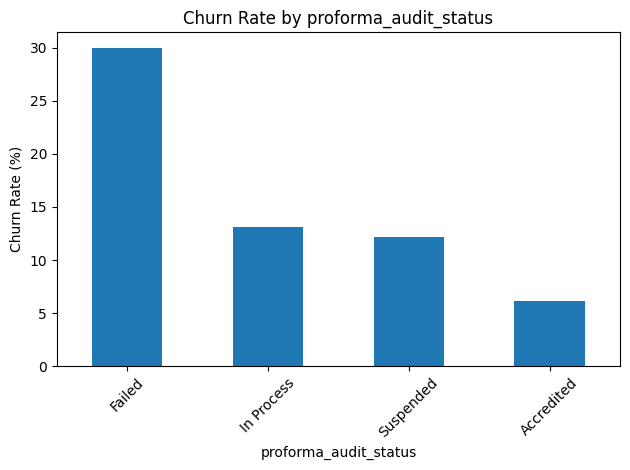

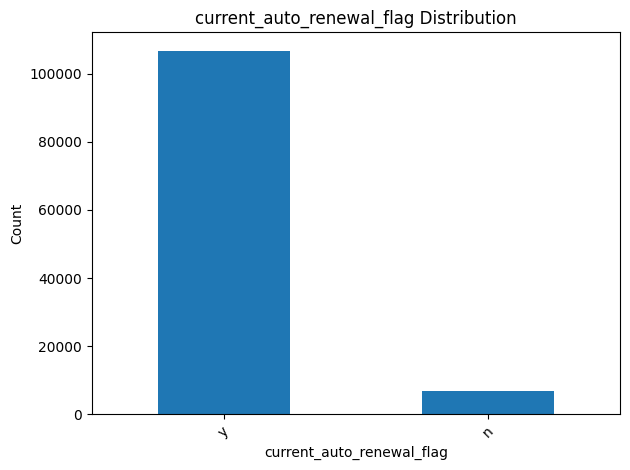

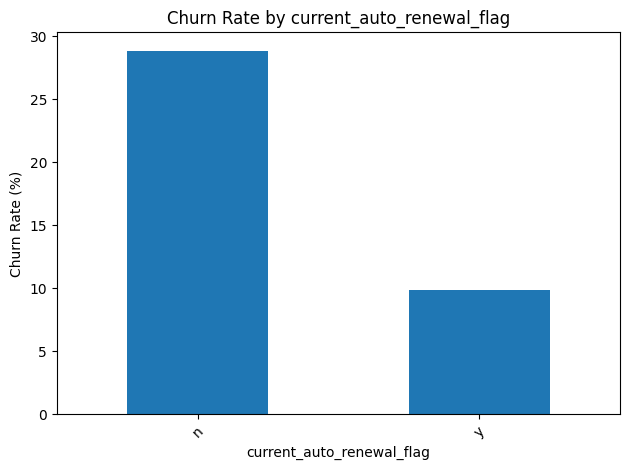

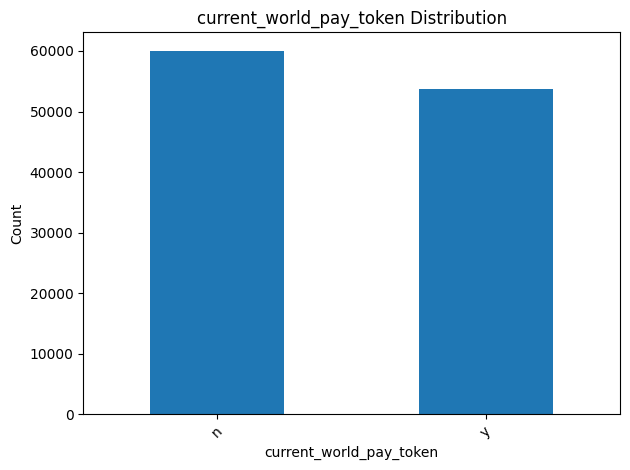

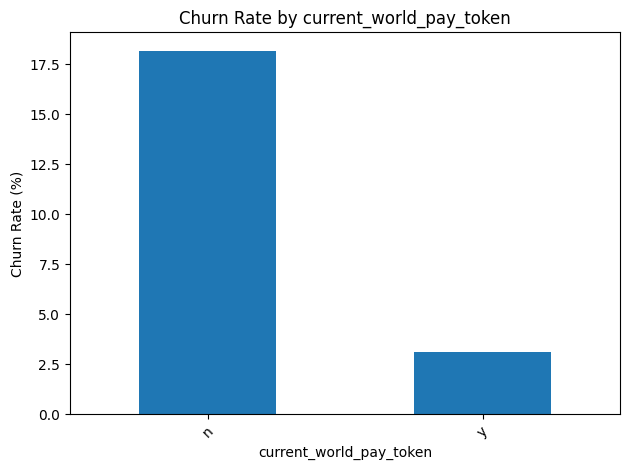

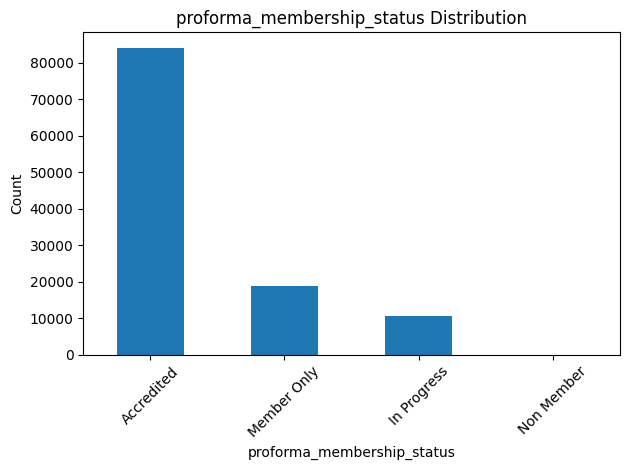

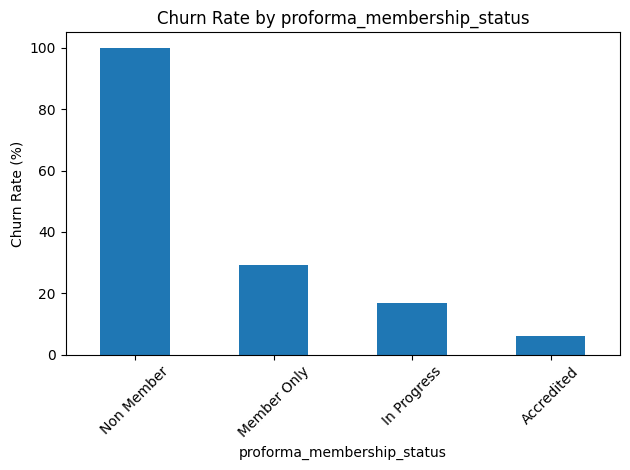

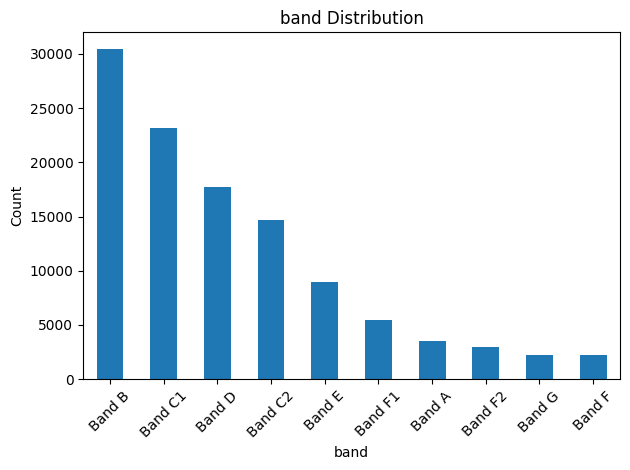

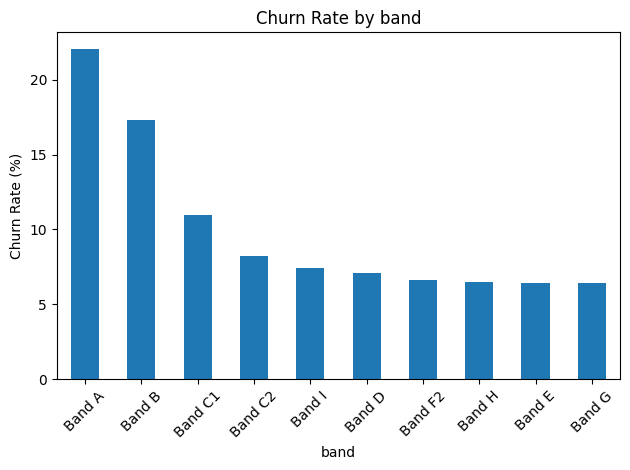

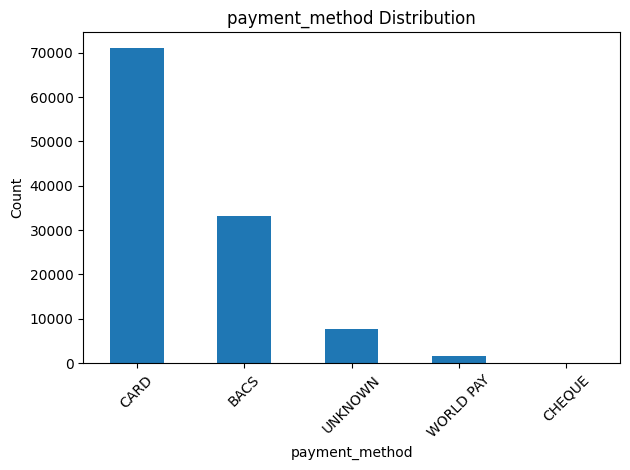

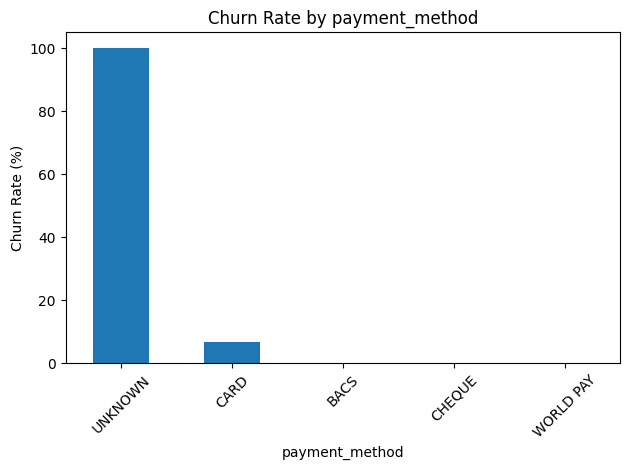

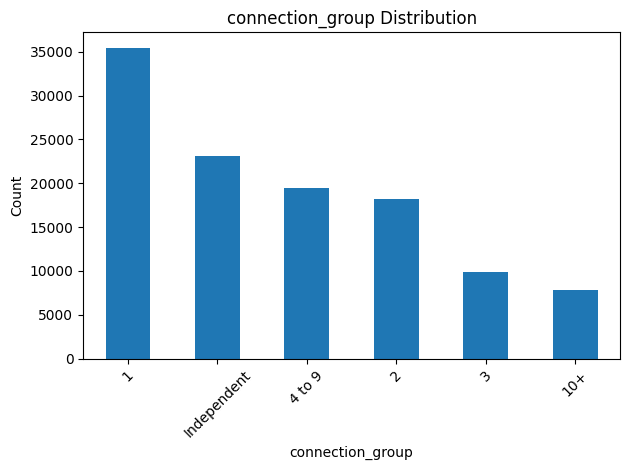

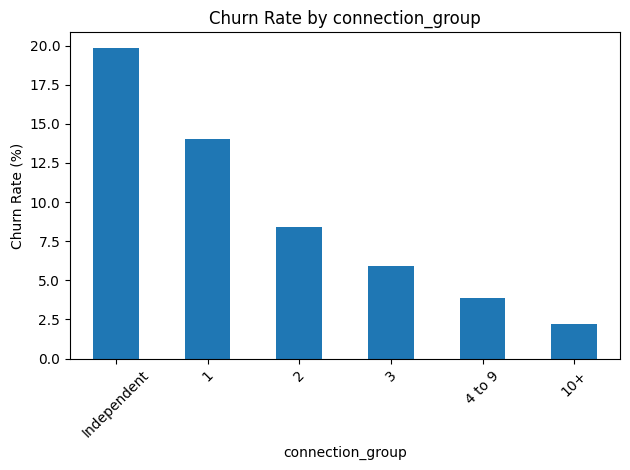

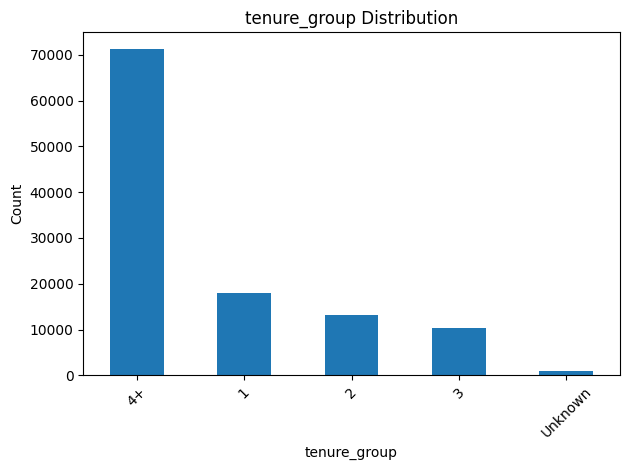

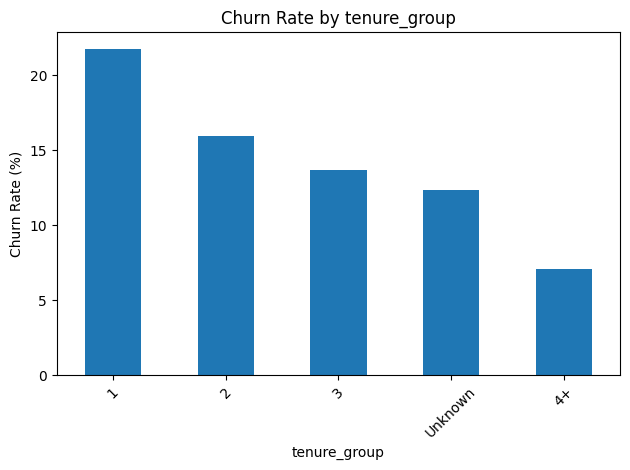

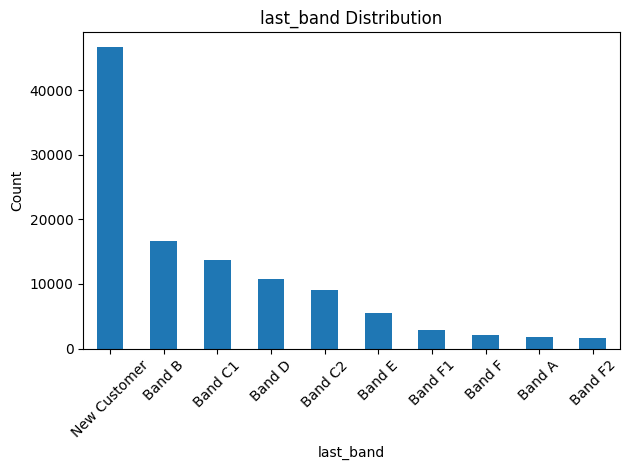

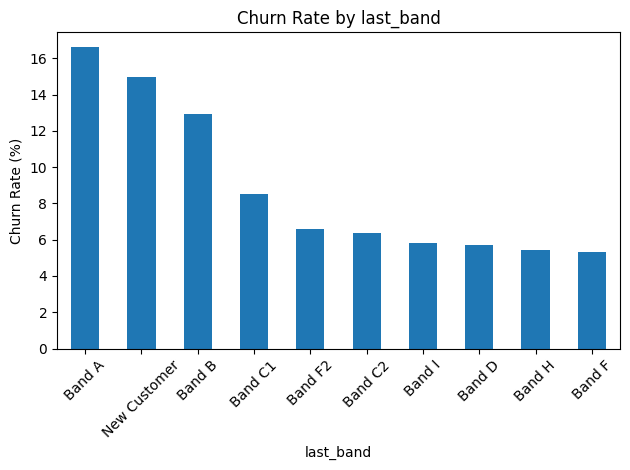

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['co_ref', 'prospect_outcome', 'prospect_status']]

for col in cat_cols:
    # Overall distribution
    counts = df[col].value_counts().head(10)
    counts.plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Churn rate per category
    churn_rate = df.groupby(col)['is_churned'].mean() * 100
    churn_rate = churn_rate.sort_values(ascending=False).head(10)
    churn_rate.plot(kind='bar')
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 7. Correlation Heatmap

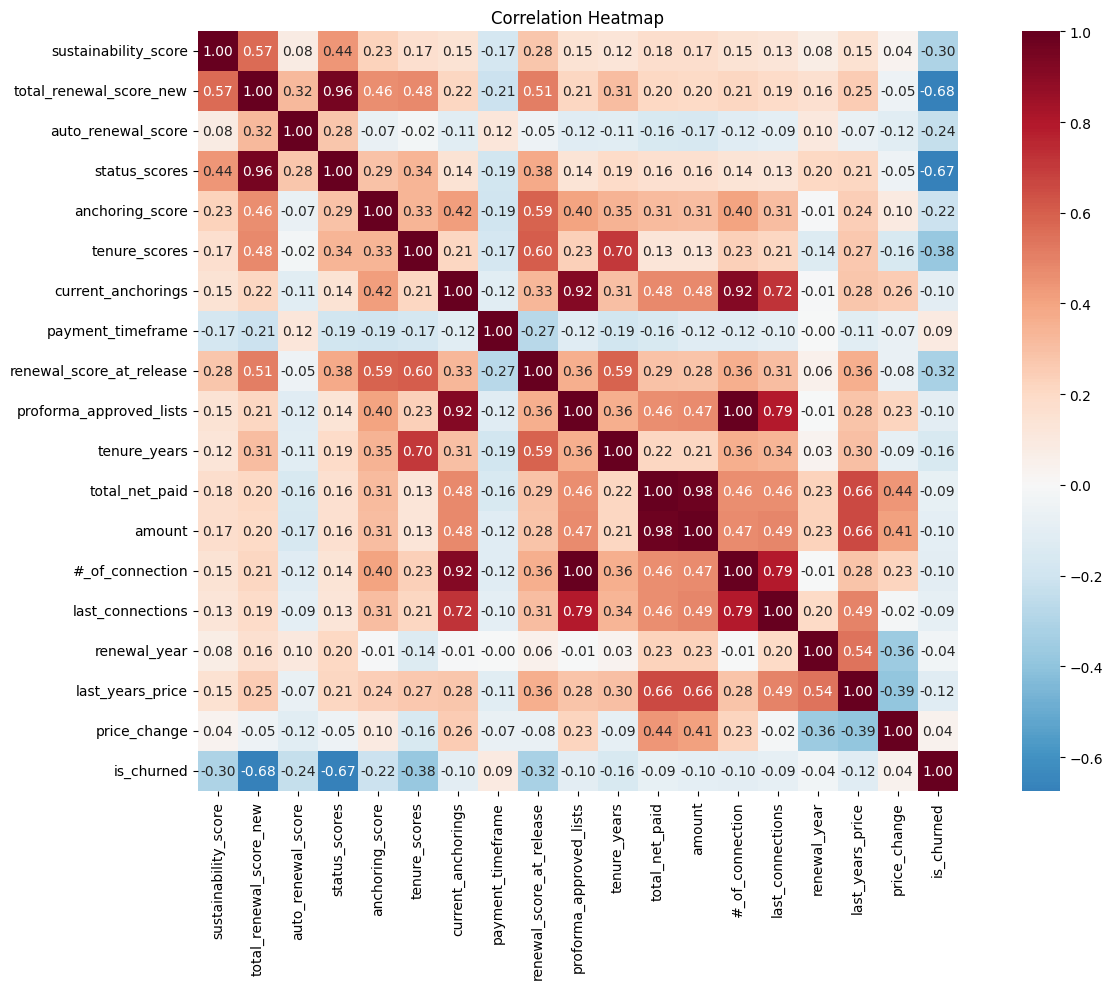

In [9]:
corr_cols = [c for c in numeric_cols if df[c].notna().sum() > len(df) * 0.5]
corr_cols.append('is_churned')

corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../../reports/figures/billings_correlation_heatmap.png')
plt.show()

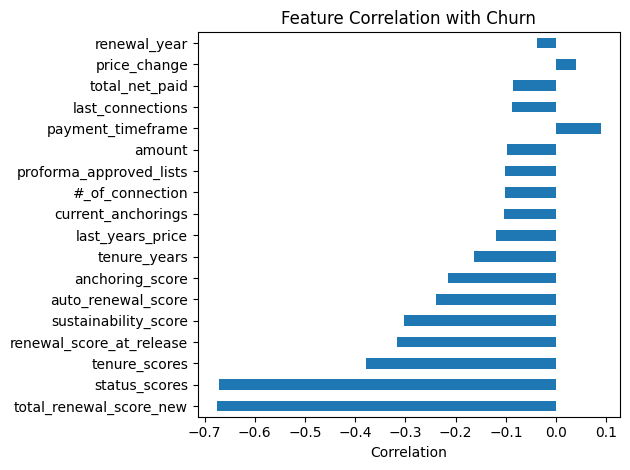

In [10]:
# Top correlations with churn
churn_corr = corr_matrix['is_churned'].drop('is_churned').sort_values(key=abs, ascending=False)
churn_corr.plot(kind='barh')
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig('../../reports/figures/billings_churn_correlation.png')
plt.show()

## 8. Temporal Analysis - Churn by Renewal Year

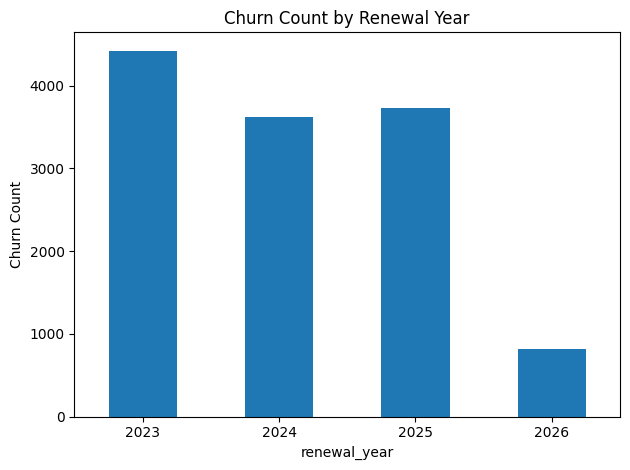

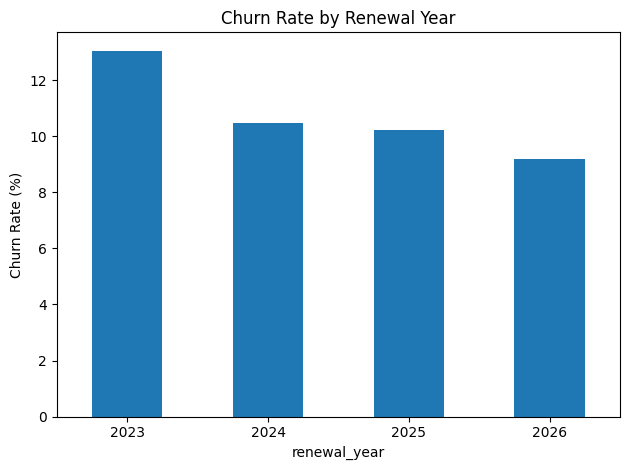

In [11]:
if 'renewal_year' in df.columns:
    churn_by_year = df.groupby('renewal_year')['is_churned'].sum()
    churn_by_year.plot(kind='bar')
    plt.title('Churn Count by Renewal Year')
    plt.ylabel('Churn Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    churn_rate_year = df.groupby('renewal_year')['is_churned'].mean() * 100
    churn_rate_year.plot(kind='bar')
    plt.title('Churn Rate by Renewal Year')
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_temporal_analysis.png')
    plt.show()

## 9. Payment Method Analysis

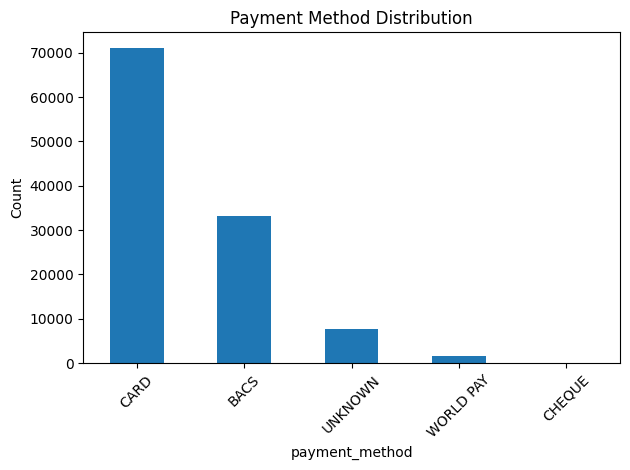

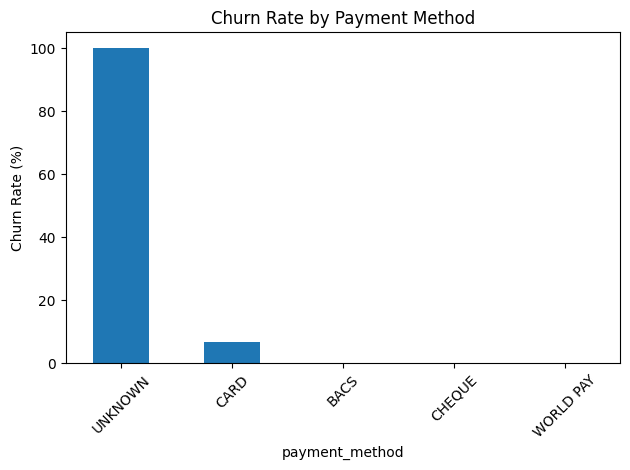

In [12]:
if 'payment_method' in df.columns:
    df['payment_method'].value_counts().plot(kind='bar')
    plt.title('Payment Method Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    churn_by_pm = df.groupby('payment_method')['is_churned'].mean() * 100
    churn_by_pm.sort_values(ascending=False).plot(kind='bar')
    plt.title('Churn Rate by Payment Method')
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_payment_method.png')
    plt.show()

## 10. Pricing Band Analysis

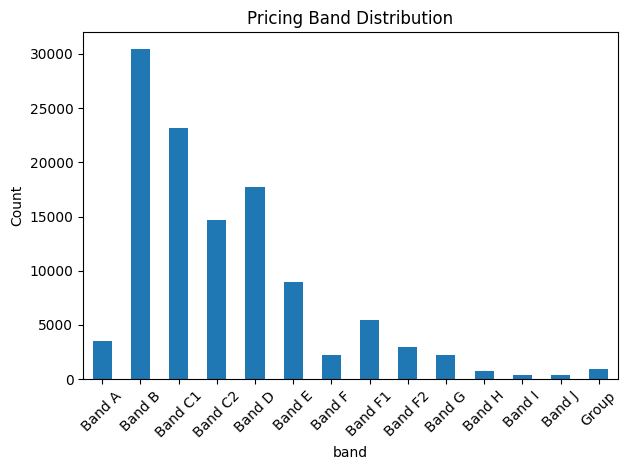

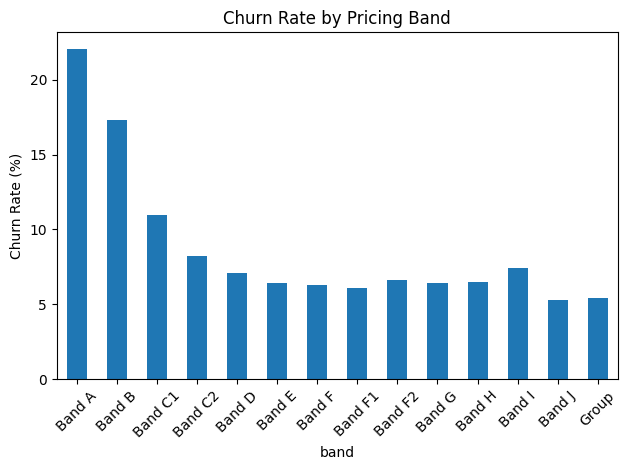

In [13]:
if 'band' in df.columns:
    df['band'].value_counts().sort_index().plot(kind='bar')
    plt.title('Pricing Band Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    churn_by_band = df.groupby('band')['is_churned'].mean() * 100
    churn_by_band.plot(kind='bar')
    plt.title('Churn Rate by Pricing Band')
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_band_analysis.png')
    plt.show()

## 11. Tenure Analysis

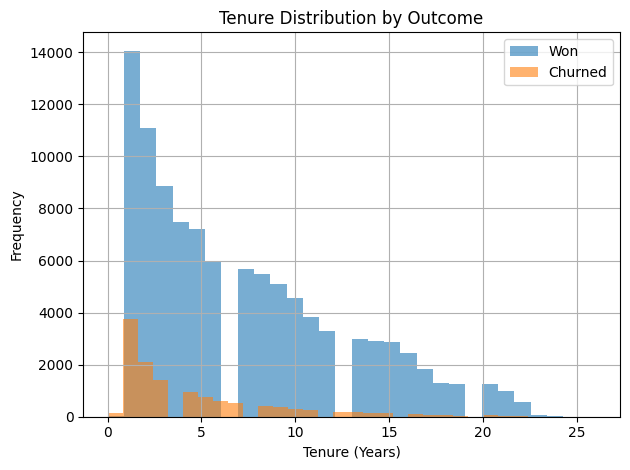

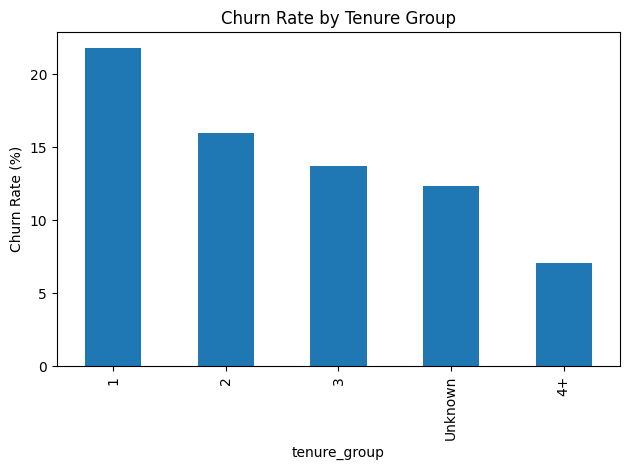

In [14]:
if 'tenure_years' in df.columns:
    df[df['prospect_outcome'] == 'Won']['tenure_years'].dropna().hist(bins=30, alpha=0.6, label='Won')
    df[df['prospect_outcome'] == 'Churned']['tenure_years'].dropna().hist(bins=30, alpha=0.6, label='Churned')
    plt.title('Tenure Distribution by Outcome')
    plt.xlabel('Tenure (Years)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

    if 'tenure_group' in df.columns:
        churn_by_tenure = df.groupby('tenure_group')['is_churned'].mean().sort_values(ascending=False) * 100
        churn_by_tenure.plot(kind='bar')
        plt.title('Churn Rate by Tenure Group')
        plt.ylabel('Churn Rate (%)')
        plt.tight_layout()
        plt.savefig('../../reports/figures/billings_tenure_analysis.png')
        plt.show()

## 12. Renewal & Score Features Analysis

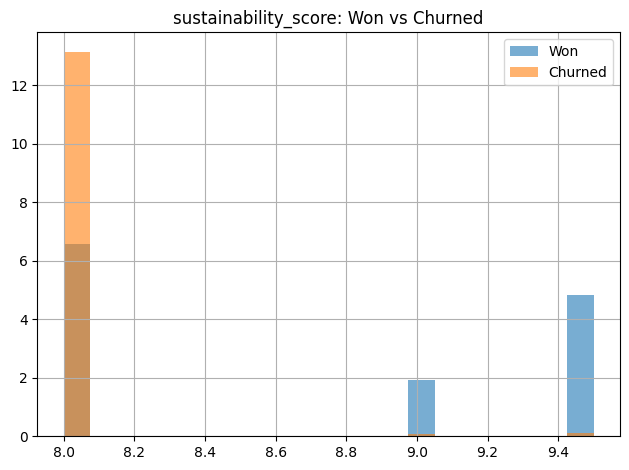

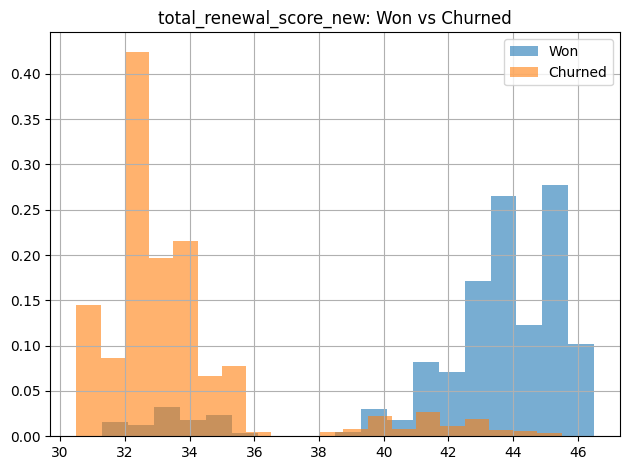

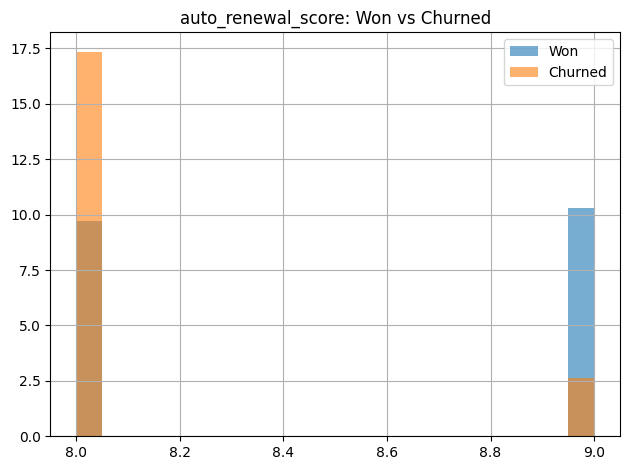

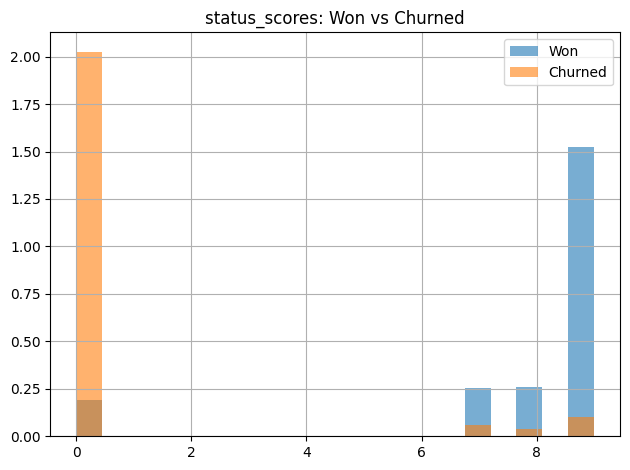

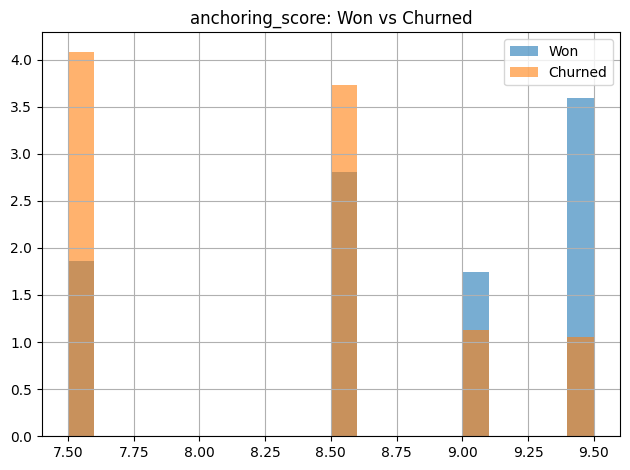

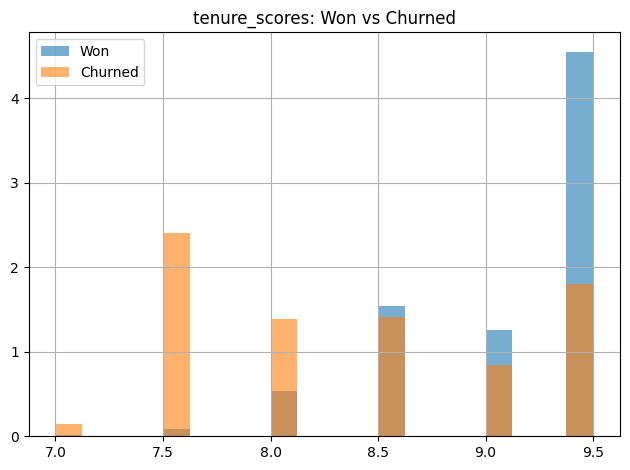

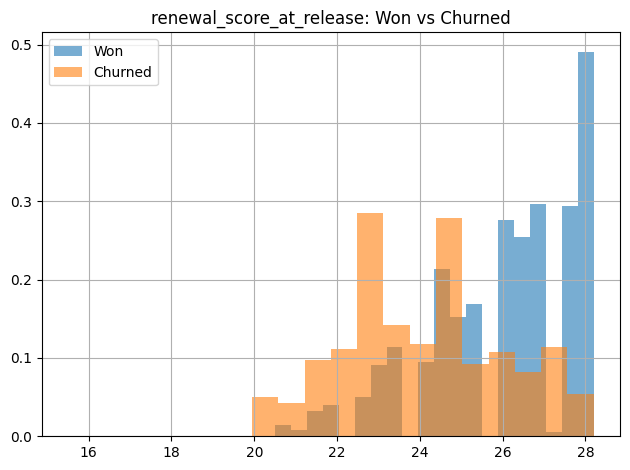

Score analysis complete


In [15]:
score_cols = ['sustainability_score', 'total_renewal_score_new', 'auto_renewal_score',
              'status_scores', 'anchoring_score', 'tenure_scores', 'renewal_score_at_release']
score_cols = [c for c in score_cols if c in df.columns]

for col in score_cols:
    df[df['prospect_outcome'] == 'Won'][col].dropna().hist(bins=20, alpha=0.6, label='Won', density=True)
    df[df['prospect_outcome'] == 'Churned'][col].dropna().hist(bins=20, alpha=0.6, label='Churned', density=True)
    plt.title(f'{col}: Won vs Churned')
    plt.legend()
    plt.tight_layout()
    plt.show()

print('Score analysis complete')

## 13. Auto-Renewal Flag Impact on Churn

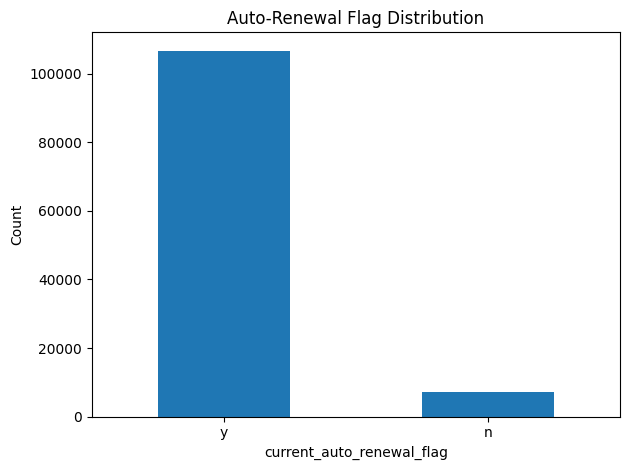

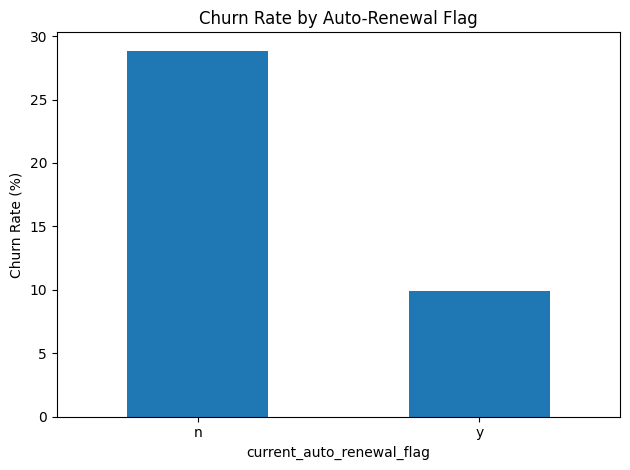

In [16]:
if 'current_auto_renewal_flag' in df.columns:
    df['current_auto_renewal_flag'].value_counts().plot(kind='bar')
    plt.title('Auto-Renewal Flag Distribution')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    churn_by_ar = df.groupby('current_auto_renewal_flag')['is_churned'].mean() * 100
    churn_by_ar.plot(kind='bar')
    plt.title('Churn Rate by Auto-Renewal Flag')
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_auto_renewal.png')
    plt.show()

## 14. Amount / Pricing Analysis

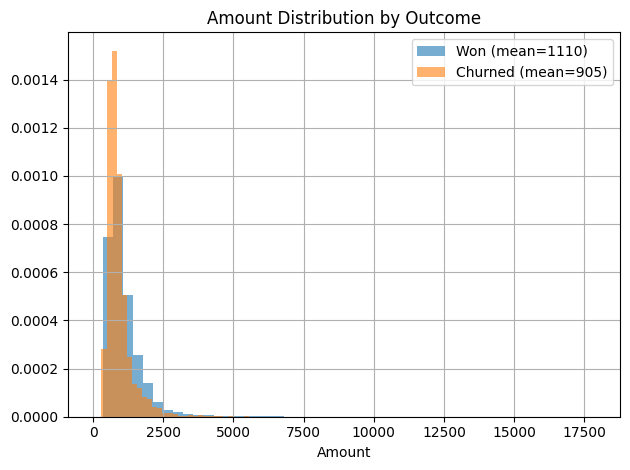

Average Amount - Won: 1110.00
Average Amount - Churned: 904.86
Median Amount - Won: 949.00
Median Amount - Churned: 749.00


In [17]:
if 'amount' in df.columns:
    won_amt = df[df['prospect_outcome'] == 'Won']['amount'].dropna()
    churned_amt = df[df['prospect_outcome'] == 'Churned']['amount'].dropna()

    won_amt.hist(bins=50, alpha=0.6, label=f'Won (mean={won_amt.mean():.0f})', density=True)
    churned_amt.hist(bins=50, alpha=0.6, label=f'Churned (mean={churned_amt.mean():.0f})', density=True)
    plt.title('Amount Distribution by Outcome')
    plt.xlabel('Amount')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_amount_analysis.png')
    plt.show()

    print(f'Average Amount - Won: {won_amt.mean():.2f}')
    print(f'Average Amount - Churned: {churned_amt.mean():.2f}')
    print(f'Median Amount - Won: {won_amt.median():.2f}')
    print(f'Median Amount - Churned: {churned_amt.median():.2f}')

## 15. Key EDA Findings Summary

In [18]:
print('=' * 60)
print('BILLINGS EDA - KEY FINDINGS SUMMARY')
print('=' * 60)
print(f'\n1. Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'2. Overall Churn Rate: {df["is_churned"].mean()*100:.1f}%')
print(f'3. Target Variable (prospect_outcome) is IMBALANCED:')
print(f'   - Won: {(df["prospect_outcome"] == "Won").sum():,}')
print(f'   - Churned: {(df["prospect_outcome"] == "Churned").sum():,}')

BILLINGS EDA - KEY FINDINGS SUMMARY

1. Dataset Shape: 113,766 rows x 36 columns
2. Overall Churn Rate: 11.1%
3. Target Variable (prospect_outcome) is IMBALANCED:
   - Won: 101,174
   - Churned: 12,592
